# **Regression**
Regression is a type of Machine Learning used to predict a continuous number.
Regression is for "How much?" or "How many?" (Numbers).

In [74]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# Setting a "seed" so the computer's random guesses stay the same every time we run it.
random_state = 70
np.random.seed(random_state)

**Data Exploration**

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010
0
age         0
sex         0
bmi         0
children    0
smoker      0
region      0

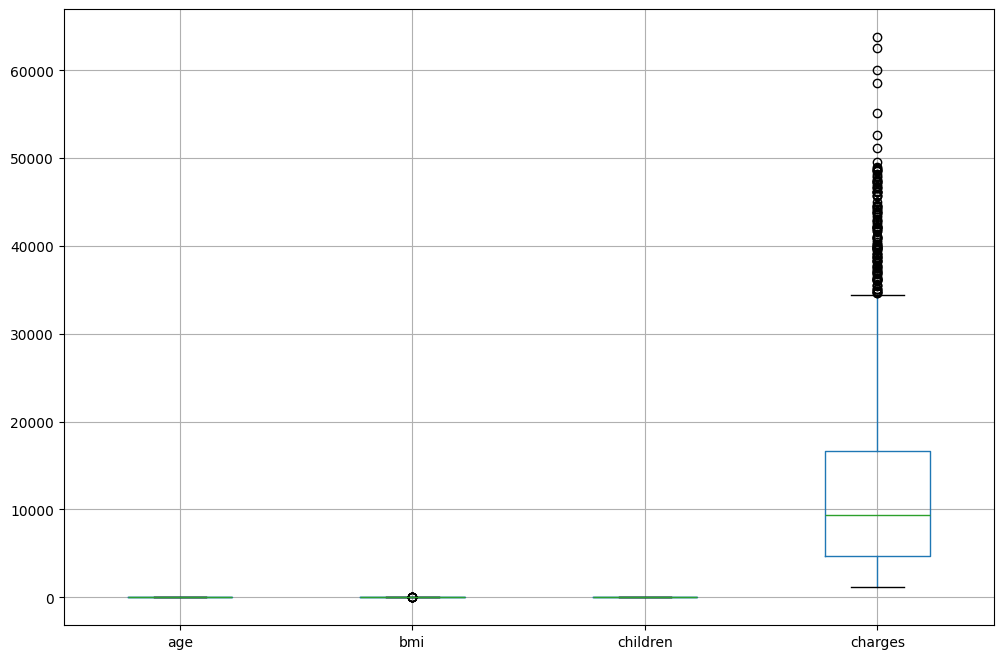

In [78]:
import seaborn as sns
url = '/content/insurance.csv'
df = pd.read_csv(url)
print(df.head())
print(df.describe())
print(df.shape[0]-df.dropna().shape[0])
print(df.isna().sum())
df.boxplot(figsize = (12,8))
plt.show()


<Axes: >

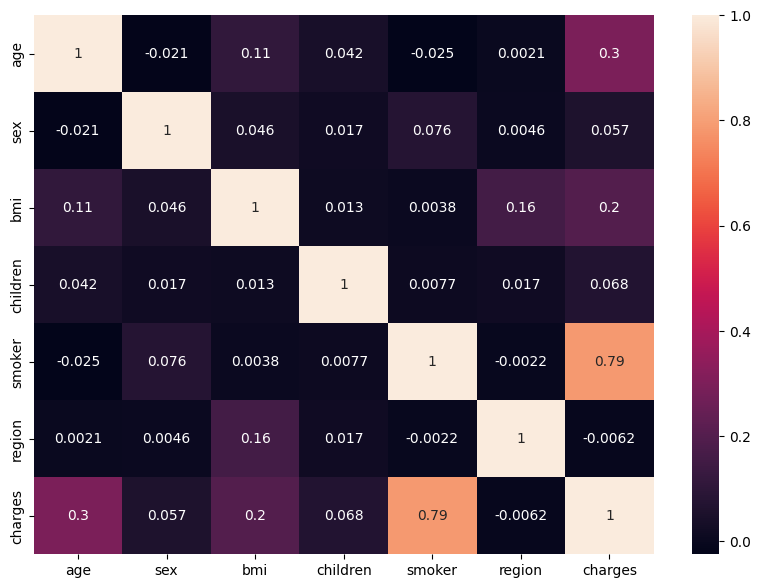

In [79]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
columns_to_transform = ['smoker', 'sex', 'region']
for col in columns_to_transform:
    df[col] = le.fit_transform(df[col])

df.head()
#now we can see the correlation better
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True)


**Data Preprocessing**

In [80]:
#drop null values
df = df.dropna()
#to convert nominal labels to numerical values
# If we use numbers like 1, 2, 3, and 4 for regions, the model might mistakenly think Region 4 is "greater than" Region 1, which isn't true.
from sklearn.preprocessing import OneHotEncoder
one = OneHotEncoder()
column_to_transform = 'region'
# Use double brackets to keep the 2D shape
enc_data = one.fit_transform(df[[column_to_transform]])
l = list(one.categories_[0])
enc_df = pd.DataFrame(enc_data.toarray(),columns=l)
df = df.join(enc_df)
df = df.drop([column_to_transform],axis=1)
df.head()

,age,sex,bmi,children,smoker,charges,0,1,2,3
0,19,0,27.900,0,1,16884.92400,0.0,0.0,0.0,1.0
1,18,1,33.770,1,0,1725.55230,0.0,0.0,1.0,0.0
2,28,1,33.000,3,0,4449.46200,0.0,0.0,1.0,0.0
3,33,1,22.705,0,0,21984.47061,0.0,1.0,0.0,0.0
4,32,1,28.880,0,0,3866.85520,0.0,1.0,0.0,0.0


In [83]:
#feature scaling
from sklearn.preprocessing import MinMaxScaler
# Force all column names to be strings
df.columns = df.columns.astype(str)
scaler = MinMaxScaler()
df_processed = pd.DataFrame(scaler.fit_transform(df),columns=df.columns)

In [84]:
# Data standardization
# Standardization = Transforming data so that the average is 0 and the spread (Standard Deviation) is 1.
from sklearn.preprocessing import PowerTransformer,StandardScaler
from sklearn.pipeline import make_pipeline
preprocessor = make_pipeline(PowerTransformer(),StandardScaler())
df_processed = pd.DataFrame(preprocessor.fit_transform(df),columns=df.columns)

In [85]:
target = 'charges'
X = df.drop(target,axis=1)
y = df[target]

**Training**

In [86]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=random_state, train_size=0.7 )
print(f'train size {X_train.shape[0]}, test size {X_test.shape[0]}')

train size 936, test size 402


In [87]:
results = pd.DataFrame(columns=['Model','RMSE','R_square'])


In [ ]:
# Run this to create the 'Power Feature'
# THIS IS A FEATURE ENGINEERING STEP, I DID THIS AFTER CHECKING ALL THE MODELS, TO INCREASE THE ACCURACY
# X_train['obese_smoker'] = ((X_train['bmi'] >= 30) & (X_train['smoker'] == 1)).astype(int)
# X_test['obese_smoker'] = ((X_test['bmi'] >= 30) & (X_test['smoker'] == 1)).astype(int)
# X_train['age_smoker'] = X_train['age'] * X_train['smoker']
# X_test['age_smoker'] = X_test['age'] * X_test['smoker']

**Modeling**

In [88]:
# Choose the feature that has the hiest correlation with the target
# UNIVARIATE LINEAR REGRESSION
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,root_mean_squared_error

feature_selected = 'smoker'
X_train_univariate = X_train[feature_selected].values.reshape(-1,1)
X_test_univariate = X_test[feature_selected].values.reshape(-1,1)

lr = LinearRegression()
lr.fit(X_train_univariate,y_train)
y_pred_univariate = lr.predict(X_test_univariate)

# regression function
coeff_univariate = lr.coef_[0] # Coefficient of the feature
intercept_univariate = lr.intercept_ # Bias

result_univariate = results.loc[len(results)] = [
    f'Linear Univariate on {feature_selected}',
    root_mean_squared_error(y_test,y_pred_univariate),
    r2_score(y_test,y_pred_univariate)
]

This is for testing, and finding the f_test.

In [89]:
import numpy as np
import scipy.stats

def f_test(y_true, y_pred, n_var, n_obs):
    """
    Computation of F-statistic and p-value for the regression
    Arguments:
    y_true: ground truth
    y_pred: predictions
    n_var: number of predicting variables
    n_obs: number of observations
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n = n_obs
    p = n_var + 1 # number of regression parameters (coefficients + intercept)

    y_true_m = np.mean(y_true)
    SSM = np.sum((y_pred - y_true_m)**2)
    SSE = np.sum((y_true - y_pred)**2)

    DFM = p - 1 # degrees of freedom for model
    DFE = n - p # degrees of freedom for error

    MSM = SSM / DFM
    MSE = SSE / DFE

    F = MSM / MSE
    p_val = 1 - scipy.stats.f.cdf(F, DFM, DFE)

    return F, p_val

In [90]:
print(result_univariate)
F_stat, p_val = f_test(y_test, y_pred_univariate, 1, len(y_test))

print(f"F-Statistic: {F_stat}")
print(f"P-Value: {p_val}")

['Linear Univariate on smoker', 7789.049876735754, 0.5803455858383582]
F-Statistic: 592.3220571532842
P-Value: 1.1102230246251565e-16


In [91]:
#multivariate linear regressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_multivariate = lr.predict(X_test)

# regression function
coeff_multivariate = lr.coef_ # Coefficient of the feature
intercept_multivariate = lr.intercept_ # Bias

result_multivariate = results.loc[len(results)] = [
    f'Linear Multivariate',
    mean_squared_error(y_test,y_pred_multivariate),
    r2_score(y_test,y_pred_multivariate)
]

In [92]:
print(result_multivariate)
F_stat, p_val = f_test(y_test, y_pred_multivariate, 1, len(y_test))

print(f"F-Statistic: {F_stat}")
print(f"P-Value: {p_val}")

['Linear Multivariate', 39330717.05700298, 0.7279462664965166]
F-Statistic: 1112.6045689604196
P-Value: 1.1102230246251565e-16


In [93]:
#decision tree regressor
# Find the Max Depth of the tree by running the algorithm normally

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=random_state)
dt.fit(X_train,y_train)
max_depth = dt.tree_.max_depth
print("The maximum depth of the full Decision Tree Regressor is {}".format(max_depth))
# Now Search the Best tree depth with cross validation
from sklearn.model_selection import GridSearchCV

paramGrid = {'max_depth':[*range(1,max_depth+1)]}

dt_gscv = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=random_state),
    param_grid=paramGrid,
    scoring='neg_mean_squared_error'
)
dt_gscv.fit(X_train,y_train)
dt_best = dt_gscv.best_estimator_
best_max_depth = dt_best.tree_.max_depth
print("The optimal maximum depth for the decision tree is {}".format(best_max_depth))

y_pred_dt = dt_best.predict(X_test)
results_DT = results.loc[len(results)] = [
    f'Decision Tree',
    mean_squared_error(y_test,y_pred_dt),
    r2_score(y_test,y_pred_dt)
]
print(results_DT)

The maximum depth of the full Decision Tree Regressor is 17
The optimal maximum depth for the decision tree is 3
['Decision Tree', 26422930.65826285, 0.8172304632721124]


In [94]:
#random forest regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=random_state)
param_grid_rf = {'max_depth':list(range(1,max_depth+1))}

rf_gscv = GridSearchCV(
    rf,
    param_grid=param_grid_rf,
    scoring = 'neg_mean_squared_error'
)
rf_gscv.fit(X_train,y_train)
rf = rf_gscv.best_estimator_

y_pred_rf = rf.predict(X_test)
result_rf = results.loc[len(results)] = [
    f'Random Forest',
    mean_squared_error(y_test,y_pred_rf),
    r2_score(y_test,y_pred_rf)
]
print(result_rf)

['Random Forest', 24193199.189329118, 0.8326536951942372]


In [95]:
#polynomial regressor
from sklearn.preprocessing import PolynomialFeatures

degrees = list(range(2,5))
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    lr_poly = LinearRegression()
    lr_poly.fit(X_train_poly,y_train)
    y_pred_poly = lr_poly.predict(X_test_poly)

    result_poly = results.loc[len(results)] = [
        f'Polynomial Regression degree {degree}',
        mean_squared_error(y_test,y_pred_poly),
        r2_score(y_test,y_pred_poly)
    ]

print(result_poly)

['Polynomial Regression degree 4', 37109071.40267247, 0.7433135681886374]


**Dusplay the results**

[Text(0.5, 0.875, 'smoker <= 0.5\nsquared_error = 147389923.202\nsamples = 936\nvalue = 13279.348'),
 Text(0.25, 0.625, 'age <= 42.5\nsquared_error = 34049044.218\nsamples = 741\nvalue = 8311.711'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'children <= 0.5\nsquared_error = 22196820.803\nsamples = 424\nvalue = 5419.983'),
 Text(0.0625, 0.125, 'squared_error = 12784828.14\nsamples = 176\nvalue = 3525.972'),
 Text(0.1875, 0.125, 'squared_error = 24523784.147\nsamples = 248\nvalue = 6764.12'),
 Text(0.375, 0.375, 'age <= 58.5\nsquared_error = 23757352.48\nsamples = 317\nvalue = 12179.512'),
 Text(0.3125, 0.125, 'squared_error = 20151558.82\nsamples = 240\nvalue = 11234.073'),
 Text(0.4375, 0.125, 'squared_error = 23526394.028\nsamples = 77\nvalue = 15126.333'),
 Text(0.75, 0.625, 'bmi <= 30.1\nsquared_error = 127969161.944\nsamples = 195\nvalue = 32156.369'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'age <= 41.0\nsquared_error = 24497356.218\nsamples = 90\nvalue = 21269.

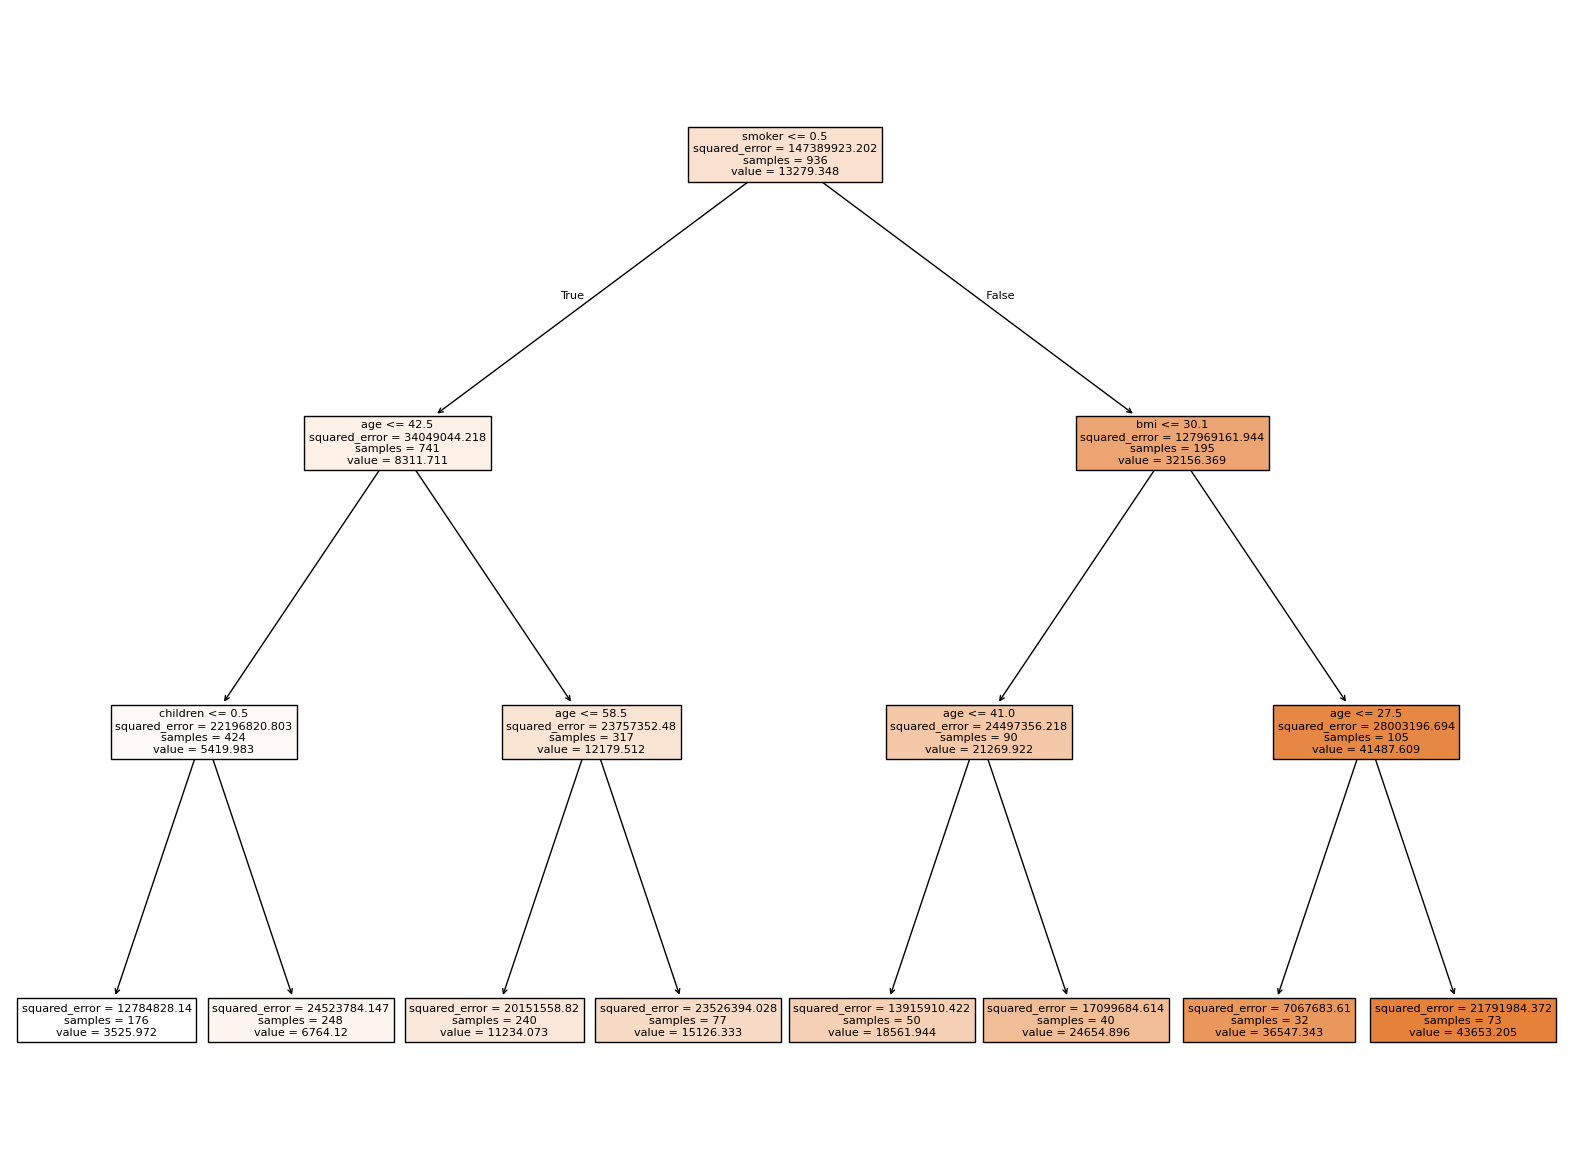

In [96]:
#display results
# Plot the Decision Tree

from sklearn.tree import plot_tree
from matplotlib.pyplot import figure

figure(figsize = (20,15))
plot_tree(dt_best,
          feature_names=X.columns.to_list(),
          filled=True
          )

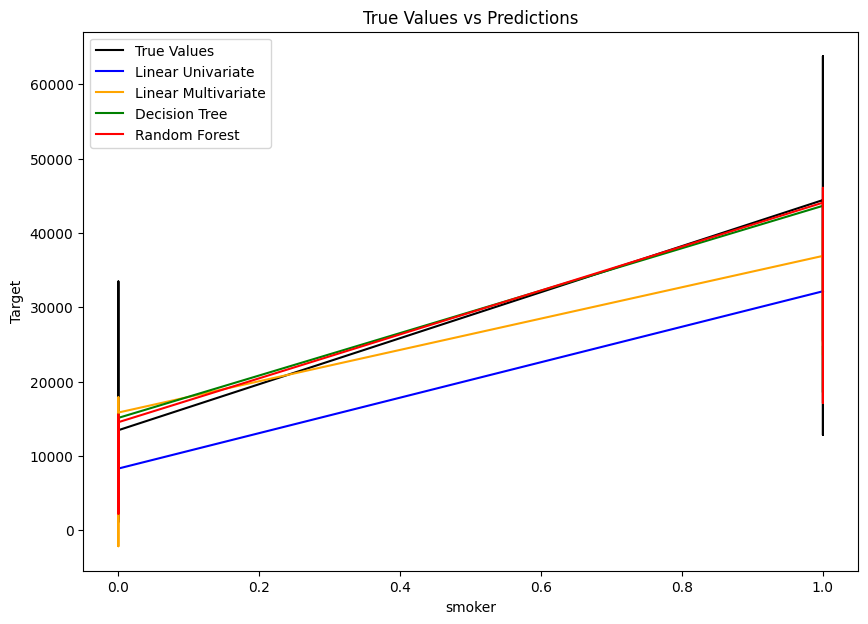

In [97]:

# Plot
# we can plot only one feature, so we choose the one with the highest correlation with the target
feature_to_plot = 'smoker'

# we need to sort the feature for incrising value to have a nice plot.
# and for that reason when need to sort also the corresponding predictions.
plot_df = pd.DataFrame()
plot_df[feature_to_plot] = X_test[feature_to_plot]
plot_df['y_test'] = y_test
plot_df['y_pred_univariate'] = y_pred_univariate
plot_df['y_pred_multivariate'] = y_pred_multivariate
plot_df['y_pred_dt'] = y_pred_dt
plot_df['y_pred_rf'] = y_pred_rf
plot_df = plot_df.sort_values(by=feature_to_plot)

# Plot the true values and the predictions of the different models
plt.figure(figsize=(10,7))
plt.plot(plot_df[feature_to_plot],plot_df['y_test'],label='True Values',color='black')
plt.plot(plot_df[feature_to_plot],plot_df['y_pred_univariate'],label='Linear Univariate',color='blue')
plt.plot(plot_df[feature_to_plot],plot_df['y_pred_multivariate'],label='Linear Multivariate',color='orange')
plt.plot(plot_df[feature_to_plot],plot_df['y_pred_dt'],label='Decision Tree',color='green')
plt.plot(plot_df[feature_to_plot],plot_df['y_pred_rf'],label='Random Forest',color='red')
plt.xlabel(feature_to_plot)
plt.ylabel('Target')
plt.legend()
plt.title('True Values vs Predictions')
plt.show()

                            Model          RMSE  R_square
3                   Random Forest  2.419320e+07  0.832654
2                   Decision Tree  2.642293e+07  0.817230
4  Polynomial Regression degree 2  2.652826e+07  0.816502
5  Polynomial Regression degree 3  2.865561e+07  0.801787
6  Polynomial Regression degree 4  3.710907e+07  0.743314
1             Linear Multivariate  3.933072e+07  0.727946
0     Linear Univariate on smoker  7.789050e+03  0.580346


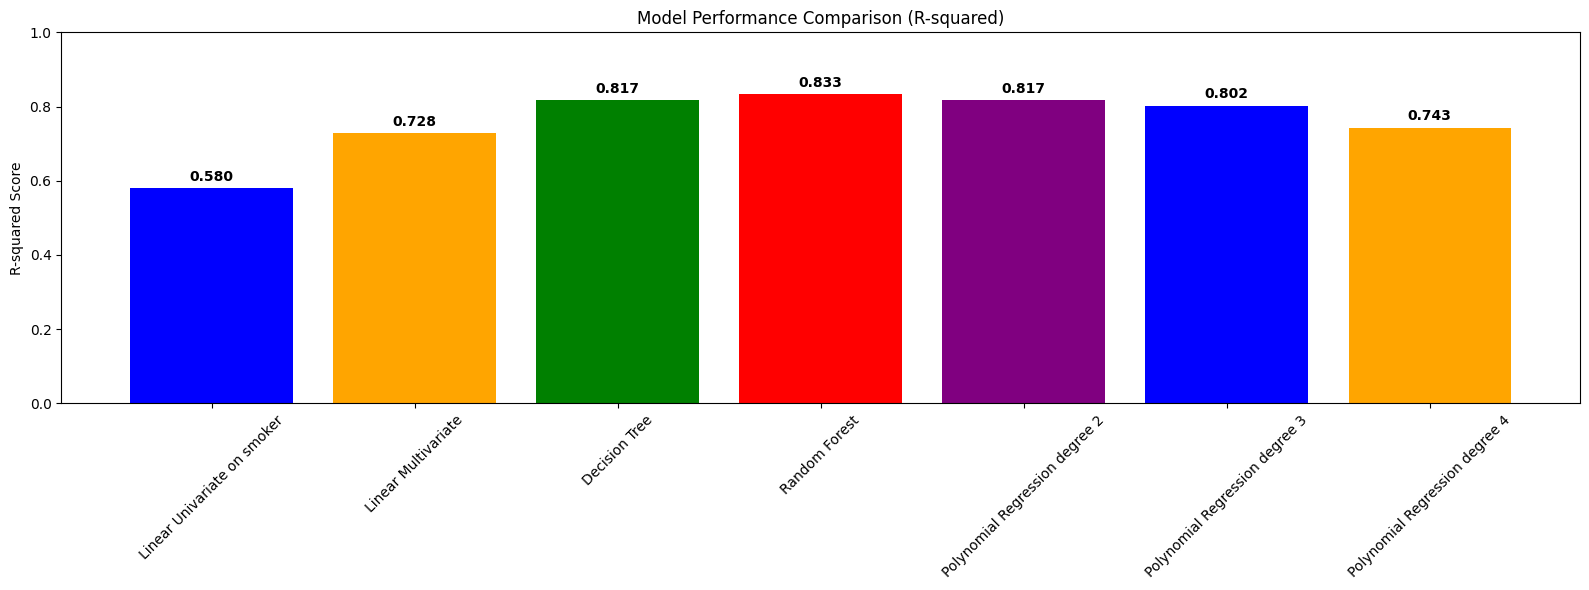

In [99]:
# Sort by R_square to see the best performing model at the top
comparison_table = results.sort_values(by='R_square', ascending=False)

# # Display the table
print(comparison_table)
import matplotlib.pyplot as plt

# Set the style
plt.figure(figsize=(16, 6))

# Create a bar chart for R_square
plt.bar(results['Model'], results['R_square'], color=['blue', 'orange', 'green', 'red', 'purple'])

# Add labels and title
plt.ylabel('R-squared Score')
plt.title('Model Performance Comparison (R-squared)')
plt.ylim(0, 1.0) # Scale from 0 to 1 for clarity

# Add the specific values on top of each bar
for i, val in enumerate(results['R_square']):
    plt.text(i, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As we can see, that random forest is giving the highest accuracy, we are going to optimize it by using grid search and Feature Engineering

In [100]:
#as random forest has maximum R_square we are gonna improve the accuracy of this model
# todo this we can do 3 things
# 1. Hyperparameter Tuning (The "Smarter Forest")
# 2. Feature Engineering (The "Better Clues")
# 3. Move to Gradient Boosting (The "Expert" Level)

# GRID SEARCH IN RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define the parameters to test
param_grid = {
    'n_estimators': [300, 500, 1000],          # More trees for better stability
    'max_depth': [5, 10, 15],                  # Preventing deep overfitting
    'min_samples_split': [2, 5, 10],           # Control how nodes split
    'min_samples_leaf': [1, 2, 4],             # Important for smoothing
    'max_features': ['sqrt', 'log2', None]     # 'None' uses all features at every split
}

# Setup the Grid Search
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3, # 3-fold cross validation
    scoring='r2',
    n_jobs=-1 # Use all processor cores to speed it up
)

rf_grid.fit(X_train, y_train)

# See the new "Best" accuracy
print(f"New Best R2 Score: {rf_grid.best_score_}")
print(f"Best Parameters: {rf_grid.best_params_}")

New Best R2 Score: 0.8732882681342212
Best Parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
